<a href="https://colab.research.google.com/github/1BM23CS345/6Sem_ML_Lab/blob/main/1BM23CS345_Lab_4_Decision_Tree_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

iris_df = pd.read_csv('/content/iris (1) - iris (1).csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Reasoning**:
The previous code failed because 'iris.csv' was not found. I have identified the correct path for the iris dataset as '/content/iris (1) - iris (1).csv' from the available files, and I will use this path to load the data.



In [2]:
import pandas as pd

iris_df = pd.read_csv('/content/iris (1) - iris (1).csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
from sklearn.model_selection import train_test_split

X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

print("Shape of X_iris_train:", X_iris_train.shape)
print("Shape of X_iris_test:", X_iris_test.shape)
print("Shape of y_iris_train:", y_iris_train.shape)
print("Shape of y_iris_test:", y_iris_test.shape)

Shape of X_iris_train: (120, 4)
Shape of X_iris_test: (30, 4)
Shape of y_iris_train: (120,)
Shape of y_iris_test: (30,)


In [5]:
from sklearn.tree import DecisionTreeClassifier


iris_tree_model = DecisionTreeClassifier()


iris_tree_model.fit(X_iris_train, y_iris_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test data
iris_predictions = iris_tree_model.predict(X_iris_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_iris_test, iris_predictions)
print(f"Accuracy Score: {accuracy:.4f}")

# Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_iris_test, iris_predictions)
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy Score: 1.0000

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [7]:
import pandas as pd

drug_df = pd.read_csv('/content/drug - drug.csv')
drug_df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [8]:
from sklearn.model_selection import train_test_split

# 1. Separate features and target variables
X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

# 2. Identify categorical features (already known from problem description: 'Sex', 'BP', 'Cholesterol')
categorical_features = ['Sex', 'BP', 'Cholesterol']

# 3. Convert categorical features using one-hot encoding
X_drug_encoded = pd.get_dummies(X_drug, columns=categorical_features, drop_first=False)

# 4. Split the data into training and testing sets
X_drug_train, X_drug_test, y_drug_train, y_drug_test = train_test_split(
    X_drug_encoded, y_drug, test_size=0.2, random_state=42
)

# 6. Print the shapes of the training and testing sets
print("Shape of X_drug_train:", X_drug_train.shape)
print("Shape of X_drug_test:", X_drug_test.shape)
print("Shape of y_drug_train:", y_drug_train.shape)
print("Shape of y_drug_test:", y_drug_test.shape)

Shape of X_drug_train: (160, 9)
Shape of X_drug_test: (40, 9)
Shape of y_drug_train: (160,)
Shape of y_drug_test: (40,)


In [9]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a Decision Tree Classifier
drug_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model using the training data
drug_tree_model.fit(X_drug_train, y_drug_train)

print("Decision Tree Classifier for drug data trained successfully.")

Decision Tree Classifier for drug data trained successfully.


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test data
drug_predictions = drug_tree_model.predict(X_drug_test)

# Calculate and print the accuracy score
accuracy_drug = accuracy_score(y_drug_test, drug_predictions)
print(f"Accuracy Score (Drug Model): {accuracy_drug:.4f}")

# Generate and print the confusion matrix
conf_matrix_drug = confusion_matrix(y_drug_test, drug_predictions)
print("\nConfusion Matrix (Drug Model):\n", conf_matrix_drug)

Accuracy Score (Drug Model): 1.0000

Confusion Matrix (Drug Model):
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


In [11]:
import pandas as pd

petrol_df = pd.read_csv('/content/petrol_consumption - petrol_consumption.csv')
petrol_df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [12]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X_petrol = petrol_df.drop('Petrol_Consumption', axis=1)
y_petrol = petrol_df['Petrol_Consumption']

# Split the data into training and testing sets (80% train, 20% test)
X_petrol_train, X_petrol_test, y_petrol_train, y_petrol_test = train_test_split(
    X_petrol, y_petrol, test_size=0.2, random_state=42
)

print("Shape of X_petrol_train:", X_petrol_train.shape)
print("Shape of X_petrol_test:", X_petrol_test.shape)
print("Shape of y_petrol_train:", y_petrol_train.shape)
print("Shape of y_petrol_test:", y_petrol_test.shape)

Shape of X_petrol_train: (38, 4)
Shape of X_petrol_test: (10, 4)
Shape of y_petrol_train: (38,)
Shape of y_petrol_test: (10,)


In [13]:
from sklearn.tree import DecisionTreeRegressor

# Instantiate a Decision Tree Regressor
petrol_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
petrol_tree_model.fit(X_petrol_train, y_petrol_train)

print("Decision Tree Regressor for petrol consumption trained successfully.")

Decision Tree Regressor for petrol consumption trained successfully.


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the test data
petrol_predictions = petrol_tree_model.predict(X_petrol_test)

# Calculate and print the evaluation metrics
mae = mean_absolute_error(y_petrol_test, petrol_predictions)
mse = mean_squared_error(y_petrol_test, petrol_predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (Petrol Model): {mae:.4f}")
print(f"Mean Squared Error (Petrol Model): {mse:.4f}")
print(f"Root Mean Squared Error (Petrol Model): {rmse:.4f}")

Mean Absolute Error (Petrol Model): 94.3000
Mean Squared Error (Petrol Model): 17347.7000
Root Mean Squared Error (Petrol Model): 131.7107


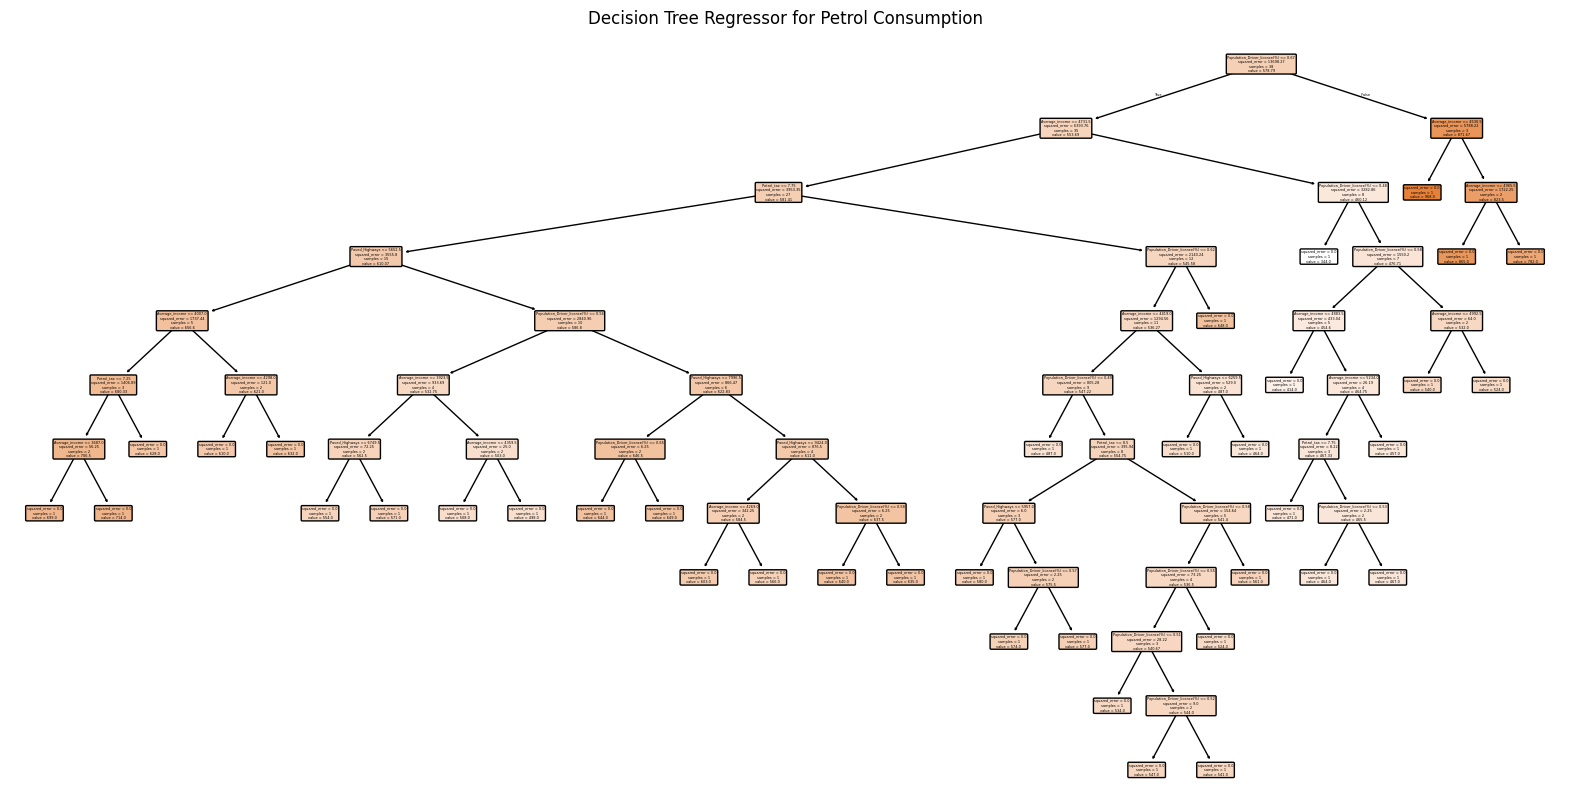


Feature Importances for Petrol Consumption Prediction:
Population_Driver_licence(%)    0.651569
Average_income                  0.240522
Petrol_tax                      0.065750
Paved_Highways                  0.042160
dtype: float64


In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the Regression Tree (you might need to adjust figsize for readability)
plt.figure(figsize=(20,10))
plot_tree(petrol_tree_model, filled=True, feature_names=X_petrol.columns, rounded=True, precision=2)
plt.title("Decision Tree Regressor for Petrol Consumption")
plt.show()

# Get feature importances
feature_importances = petrol_tree_model.feature_importances_
features = X_petrol.columns

# Create a pandas Series for better visualization
importance_df = pd.Series(feature_importances, index=features).sort_values(ascending=False)

print("\nFeature Importances for Petrol Consumption Prediction:")
print(importance_df)
